In [1]:
import sys
import os

print("Python utilisé par Jupyter:")
print(sys.executable)
print("\nVersion:")
print(sys.version)

# Remonter jusqu'au répertoire ATOMOD
notebook_dir = os.getcwd()
atomod_dir = os.path.abspath(os.path.join(notebook_dir, '..', '..'))

print(f"Répertoire notebook: {notebook_dir}")
print(f"Répertoire ATOMOD: {atomod_dir}")

sys.path.insert(0, atomod_dir)

# Maintenant l'import fonctionne
import HBPy
print("✅ HBPy importé!")


import logging
# Configuration du logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)
from pathlib import Path

from HBPy.Molecule.Crystal import Crystal,Atom

Python utilisé par Jupyter:
/home/bulou/src/essai/ATOMOD/venv/ATOMOD/bin/python3

Version:
3.10.12 (main, Mar  3 2026, 11:56:32) [GCC 11.4.0]
Répertoire notebook: /home/bulou/src/essai/ATOMOD/doc/tutorials
Répertoire ATOMOD: /home/bulou/src/essai/ATOMOD
✅ HBPy importé!


/home/bulou/src/essai/ATOMOD/venv/ATOMOD/lib/python3.10/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [2]:
    status={
        'NP':True,
        'abtem':True,
        'feff':True,
        'atomic probability map':True,
        'optimization':False,
    }
    config={
        'run_dir':'run_dir',                          # répertoire de lancement
        'simul_dir':'simul',                          # répertoire de base de la simulation
        'train':{
            'TEM_img_dir'      : "train/TEM",        # répertoire de stockage des images TEM
            'EXAFS_dir'        : "train/EXAFS",      # répertoire de stockage des spectres EXAFS
            'prob_maps_img_dir': "train/prob_maps",  # répertoire de stockage des images TEM
            'nfo_dir'          : "train/nfo",        # répertoire des infos sur la gen. in silico
            'optimizer'        : "adam",
            'BATCH_SIZE'       :  4,
        },
        'NP':{
            'status':status['NP'],
            'seed':1,
            'structure':{
                'optimization':status['optimization'],
                'composition':['Pt','Co','Au','Pd','Rh'],
                'radius':5.0,
                'a':3.92,
            },
            'nvaccum':2.0,
        },
        'abtem':{
            'status':status['abtem'],
            'dx':0.04,
            'dy':0.04,
            'dz':4.08/2,
            'energy':300e3,
            'focal spread':40,
            'semiangle cutoff':20,
            'defocus':200,
            'cell scale':1.1
        },
        'atomic presence probability map':{
            'status':status['atomic probability map'],
            'ninter':{ # nombre d'intervalles entre deux positions atomiques
                'x':20,
                'y':20,
                'z':2
            },
            'sigma': .6  # en Å, largeur de la gaussienne ~ rayon atomique ou un peu moins
        },
        'image':{
            'xmin':0.0,
            'xmax':0.0,
            'ymin':0.0,
            'ymax':0.0,
            'H':128,
            'W':128,
            },
        'exafs':{
            'N_POINTS_EXAFS': 200,   # Nombre de points par spectre
        },
        'feff':{
            'status':status['feff'],
            'parameters':{
                'TITLE':'FEFF INPUT FILE',
                'DEBYE_TEMP': 190.0,
                'SCF_RADIUS': 5.0,
                'RPATH': 5.0,     # typique 2.2xdistance plus proches voisins. changer pour étudier la cvg des spectres
                'EXAFS' : 20.0,   # xkmax - default 20 ang.^-1
                'EDGE': {'Co':'K','Ni':'K','Ru':'K','Rh':'K','Pd':'K','Ir':'L3','Pt':'L3','Au':'L3'},
                'RMAX':8.0,
                'feff_dir':  '/home/bulou/ownCloud/Notebooks/M2P2_HEA/Home/Modelisation/ATOMOD/JFEFF/feff90/unix/',
                'input_save_dir':'./',
                'filename':'feff.inp',
                'list_pgm':['rdinp','atomic','dmdw','pot',
                            'opconsat', 
                            'screen',
                            'xsph',
                            'fms',
                            'mkgtr',
                            'path', 
                            'genfmt',
                            'ff2x',
                            'sfconv',
                            'compton',
                            'eels',
                            'ldos'
                            ]
            }
        }
    }
    

    config['run_dir']=Path.cwd()

_______________________________________
# Etape 1 : construire la nanoparticules
 _______________________________________
#   Etape 1.1 : la structure

In [3]:
NP=Crystal()
NP.build(a=config['NP']['structure']['a'],
    radius=config['NP']['structure']['radius'],
    materials='NP')
NP.origin_at_mass_center()
logger.info(f"min={NP.qmin} max={NP.qmax}")
logger.info(f"Mass center={NP.MC}")
logger.info(f"Number of atoms={len(NP.atoms)}")

2026-07-05 07:01:05,775 [INFO] - <module>() - min=[-2.94 -2.94 -2.94] max=[2.94 2.94 2.94]
2026-07-05 07:01:05,776 [INFO] - <module>() - Mass center=[ 4.44089210e-16 -3.48927236e-16 -2.53765263e-16]
2026-07-05 07:01:05,777 [INFO] - <module>() - Number of atoms=28


 #   Etape 1.2 : la distribution chimique   

In [4]:
NP.set_composition(config['NP']['structure']['composition'])
directory=config['run_dir']/config['simul_dir']/str(config['NP']['seed'])/config['train']['nfo_dir']/"XYZ"
NP.save(prefix="NP",fmt='xyz',savedir=directory)

#   Etape 1.3 : (optionnelle) l'optimisation structurale et/ou chimique

In [5]:
 if config['NP']['structure']['optimization']:
     NP.optimize_ase()

In [6]:
import py3Dmol

chemin_fichier = directory/"NP.xyz"
xyz_data = chemin_fichier.read_text(encoding="utf-8")
vue = py3Dmol.view(width=400, height=400)
vue.addModel(xyz_data, "xyz")
vue.setStyle({'sphere': {'colorscheme': 'Jmol', 'scale': 1.0}, 'spacefill': {}})
vue.zoomTo()
vue.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

 ___________________________________________________________________
# Etape 2 : construire les cartes de probabilité de présence atomique
___________________________________________________________________

2026-07-05 07:01:06,346 [INFO] - xyz2slice() - Number of plane(s) along x: 4
2026-07-05 07:01:06,348 [INFO] - xyz2slice() - Mean interplane distancealong x: 1.9588254921588255
2026-07-05 07:01:06,349 [INFO] - xyz2slice() -  [1.76176176e-03 1.95795796e+00 3.92204204e+00 5.87823824e+00]
2026-07-05 07:01:06,632 [INFO] - xyz2slice() - Number of plane(s) along y: 4
2026-07-05 07:01:06,632 [INFO] - xyz2slice() - Mean interplane distancealong y: 1.9588254921588255
2026-07-05 07:01:06,633 [INFO] - xyz2slice() -  [1.76176176e-03 1.95795796e+00 3.92204204e+00 5.87823824e+00]
2026-07-05 07:01:06,936 [INFO] - xyz2slice() - Number of plane(s) along z: 4
2026-07-05 07:01:06,937 [INFO] - xyz2slice() - Mean interplane distancealong z: 1.9588254921588255
2026-07-05 07:01:06,937 [INFO] - xyz2slice() -  [1.76176176e-03 1.95795796e+00 3.92204204e+00 5.87823824e+00]
2026-07-05 07:01:06,938 [INFO] - xyz2slice() - x: d=0.09794127460794128 Npts=140
2026-07-05 07:01:06,939 [INFO] - xyz2slice() - y: d=0.0979412

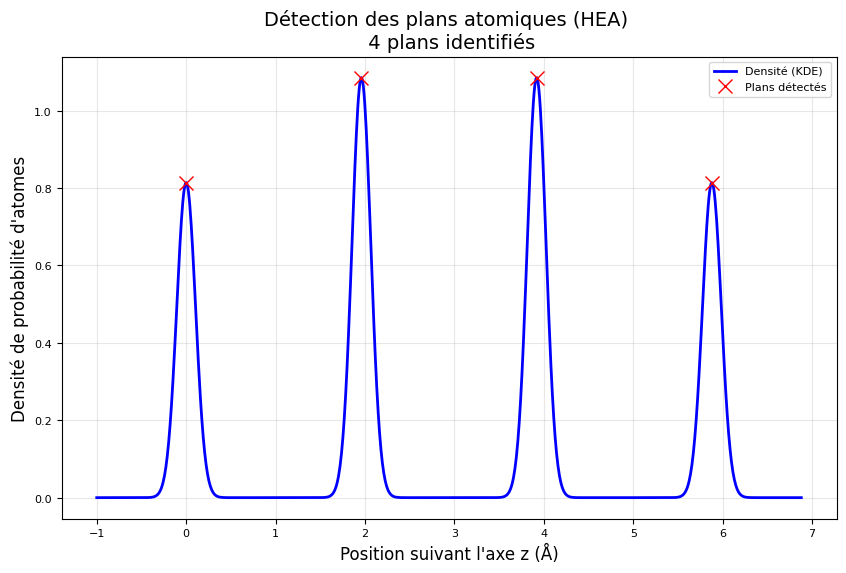

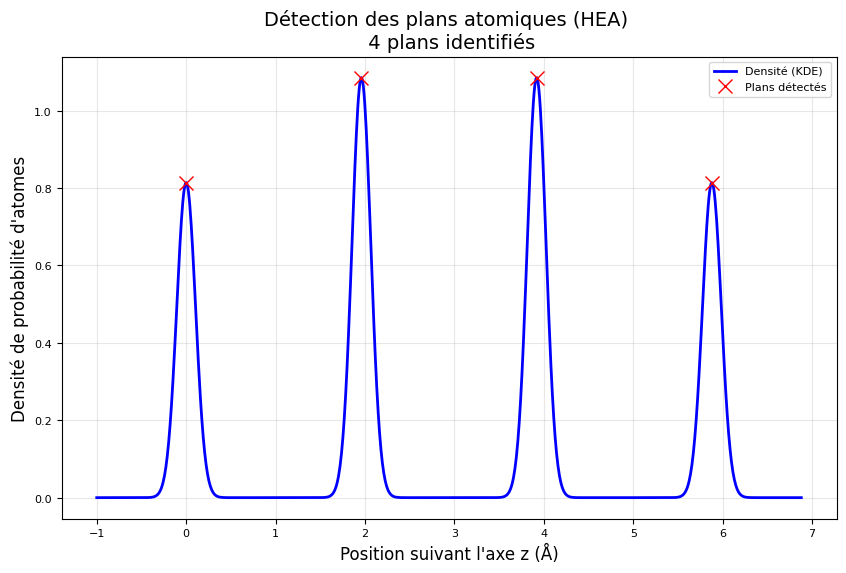

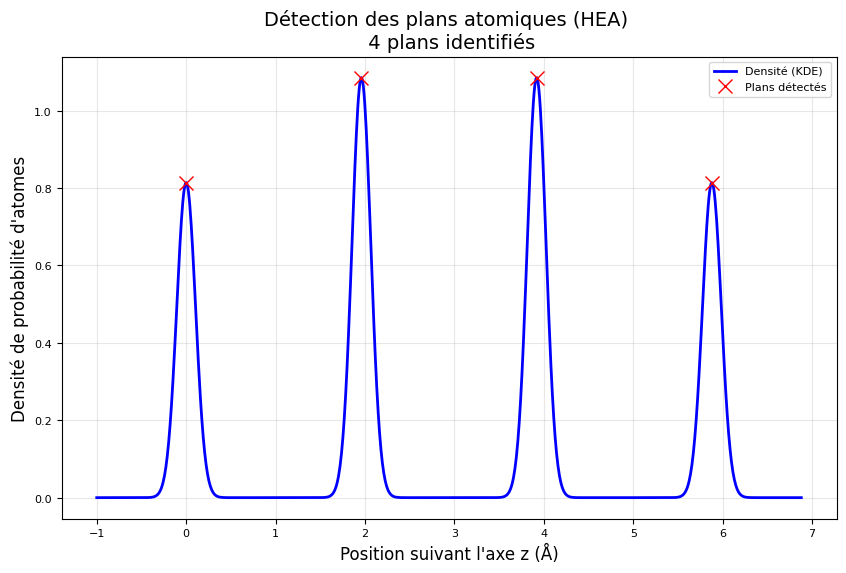

In [7]:
 if config['atomic presence probability map']['status']:
     directory=config['run_dir']/config['simul_dir']/str(config['NP']['seed'])/config['train']['prob_maps_img_dir']
     NP.xyz2slice(config,savedir=directory)
     logger.info(f"{NP.qmin[0]} {NP.qmax[0]} {NP.qmin[1]} {NP.qmax[1]}")
     logger.info(f"{config['image']['xmin']} {config['image']['xmax']} {config['image']['ymin']} {config['image']['ymax']}")


___________________________________________________________________
# Etape 3 : construire l'image TEM
    abTEM : https://github.com/abTEM/abTEM
    https://abtem.readthedocs.io/en/latest/intro.html
___________________________________________________________________
   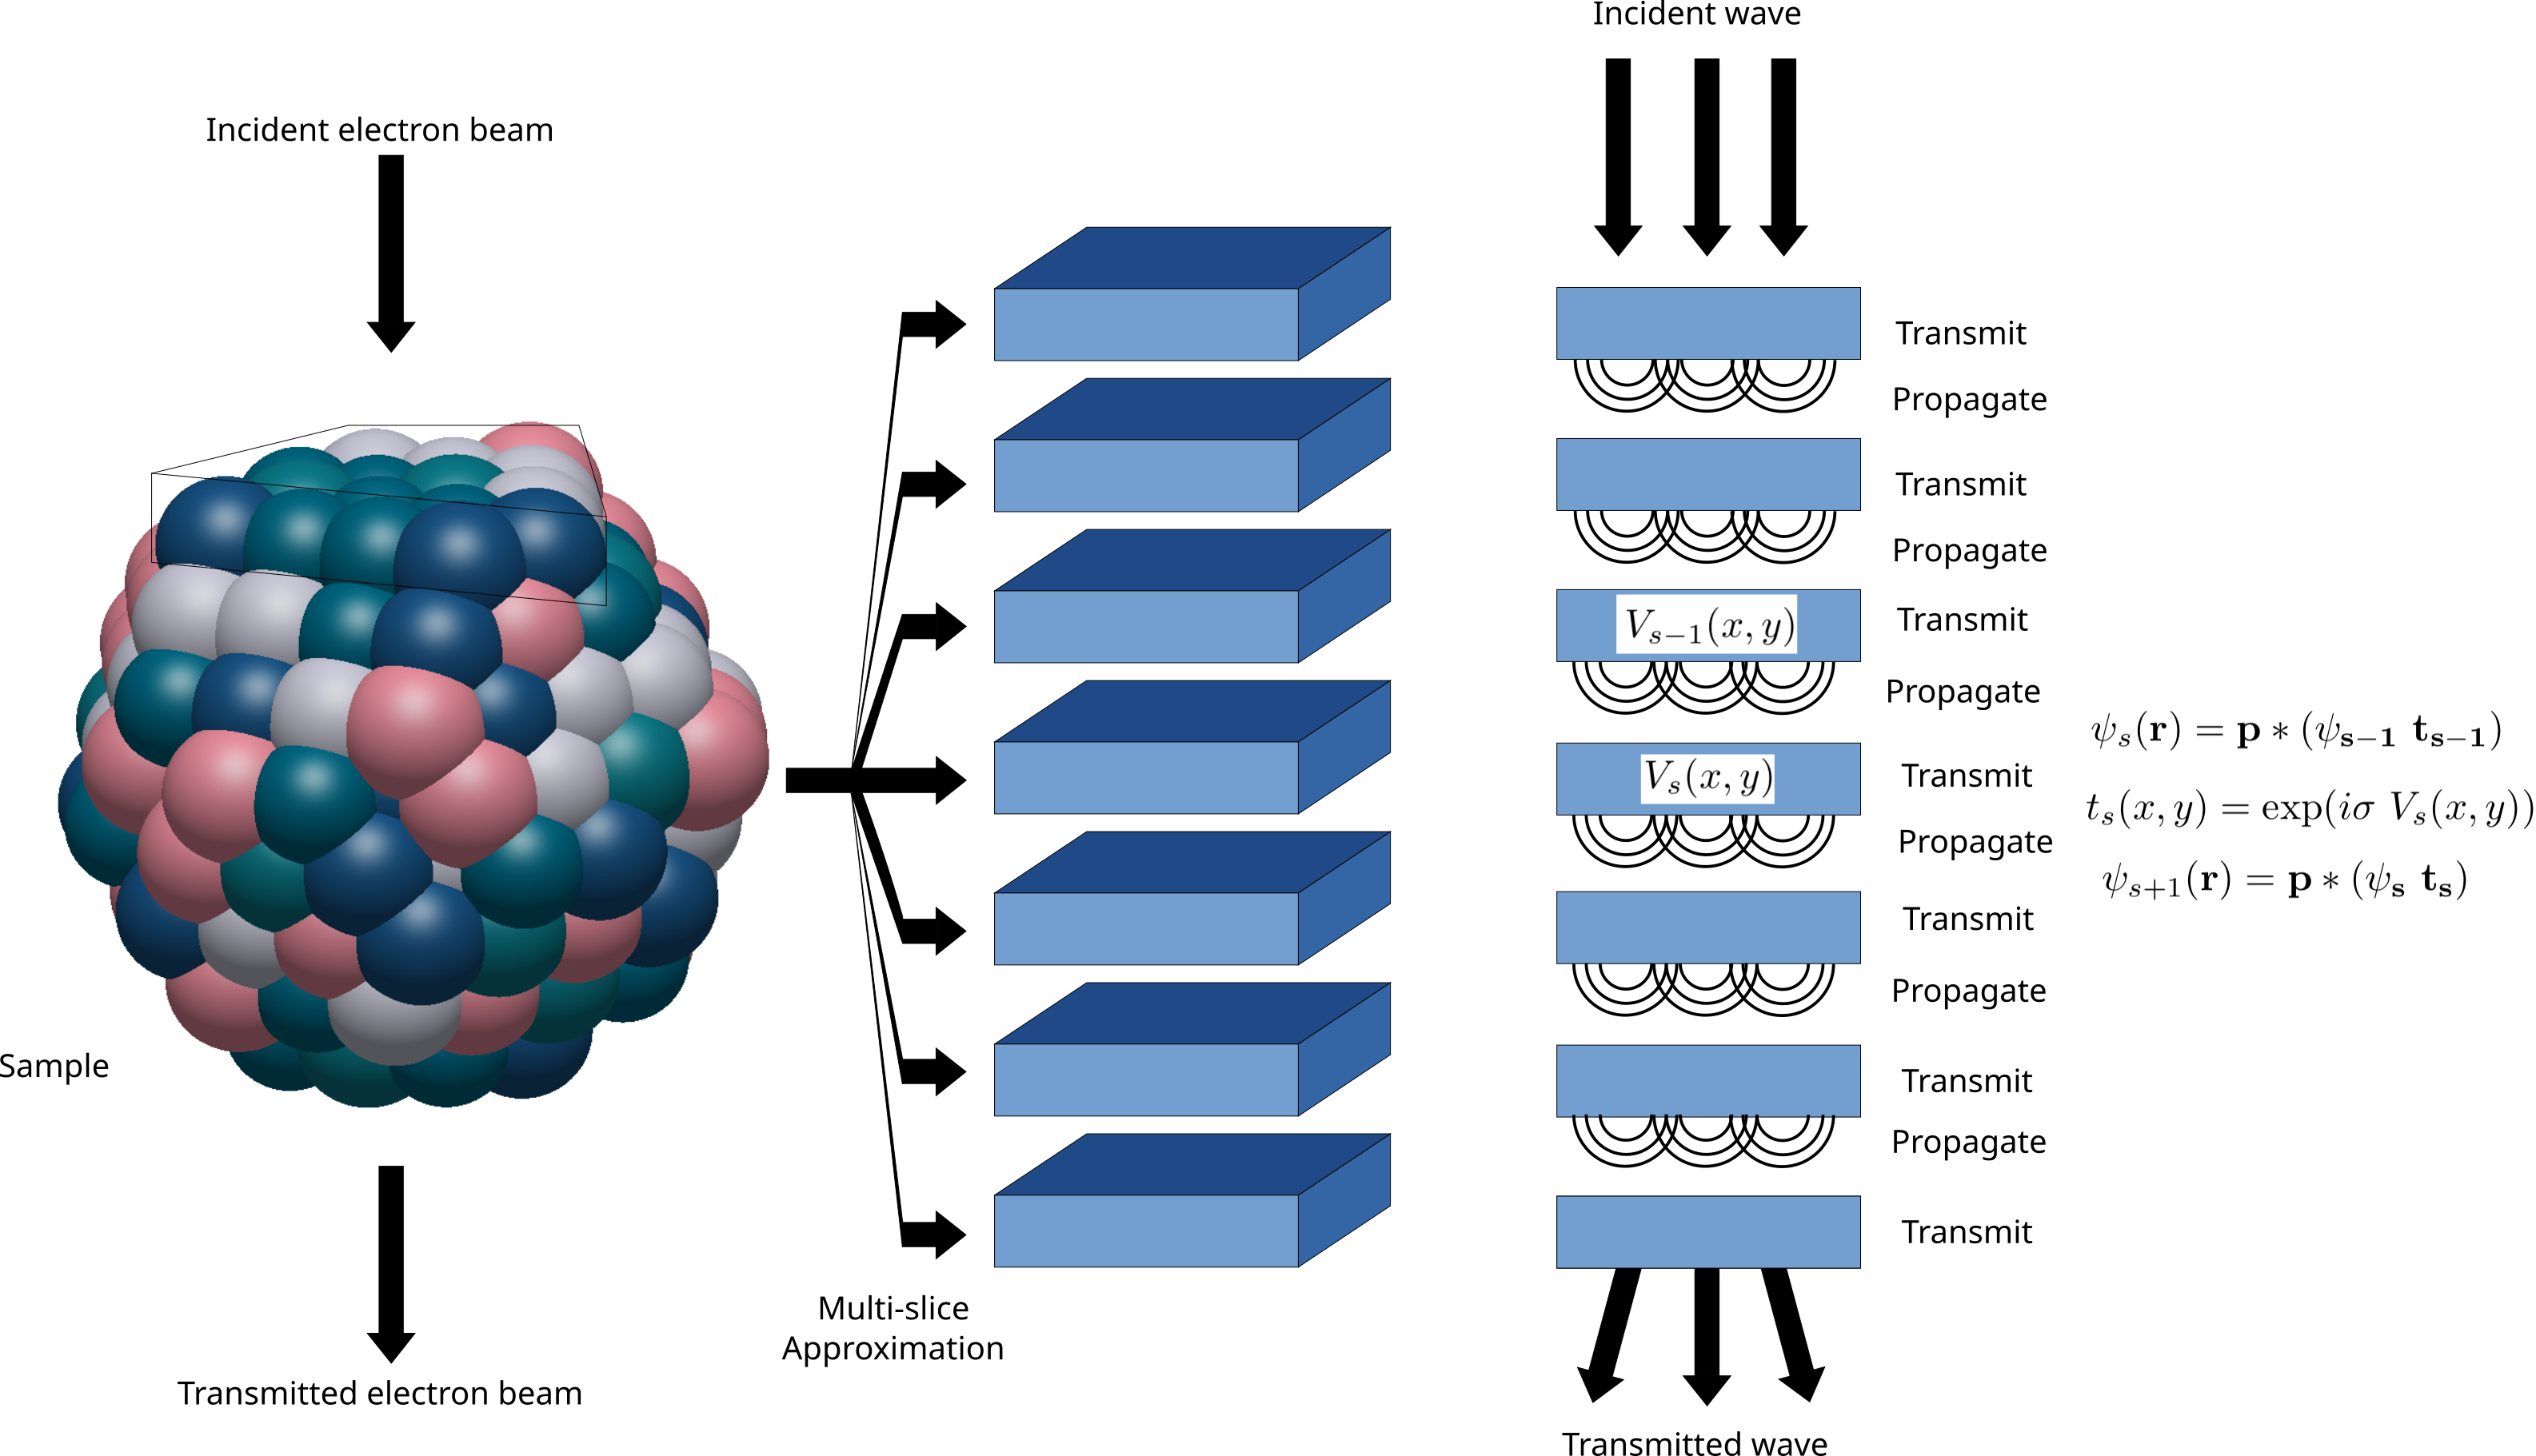

Les images TEM sont simulée dans le cadre de la méthode multislice. Le principe de cette méthode repose sur la modélisation de la diffusion des électrons à travers un échantillon (comme une nanoparticule) en suivant le formalisme mathématique de Cowley-Moodie (1957).
L'idée de base est qu'un échantillon est en général trop épais pour être traité d'un seul coup. On le découpe en tranches fines (2–5 Å), et on propage l'onde électronique tranche par tranche.
Les principales étapes de l'approche multislice sont :
1. Le découpage de l'échantillon : Le modèle atomique 3D est positionné face au faisceau d'électrons incident, puis il est virtuellement découpé en une série de tranches parallèles très fines, perpendiculaires à l'axe de propagation du faisceau (l'axe z). L'épaisseur de ces tranches est généralement définie autour de 0.2 nm (ou 2 Å)
2. L'interaction tranche par tranche : Chaque tranche est considérée mathématiquement comme un réseau de phase. La méthode calcule le potentiel électrostatique projeté pour chaque tranche, ce qui définit sa fonction de transmission.
3. La propagation itérative : L'interaction entre l'onde électronique et la matière est calculée de manière récursive. La fonction d'onde de l'électron traverse la première tranche (transmission), puis l'algorithme calcule sa propagation (propagation de Fresnel) jusqu'à la tranche suivante, et ainsi de suite jusqu'à traverser entièrement l'échantillon

Nous utilisons abTEM, un package Python open-source qui simule des images de microscopie électronique en transmission (TEM/STEM) à partir de structures atomiques.



2026-07-05 07:01:16,956 [INFO] - abTEM() - TEM images directory = /home/bulou/src/essai/ATOMOD/doc/tutorials/simul/1/train/TEM
2026-07-05 07:01:16,958 [INFO] - abTEM() - Cell size: 13.715301968635302
2026-07-05 07:01:16,964 [INFO] - abTEM() - slice_thickness= 2.04  sampling=0.04
2026-07-05 07:01:16,967 [INFO] - abTEM() - potential extansion: (13.715301968635302, 13.715301968635302)
2026-07-05 07:01:16,968 [INFO] - abTEM() - potential origin: (0.0, 0.0, 0.0)
2026-07-05 07:01:16,969 [INFO] - abTEM() - potential shape: (7, 343, 343)


[########################################] | 100% Completed | 1.98 ss


2026-07-05 07:01:18,998 [INFO] - abTEM() - sampling=(0.03998630311555482, 0.03998630311555482)
2026-07-05 07:01:18,998 [INFO] - abTEM() - extent=(13.715301968635302, 13.715301968635302)
2026-07-05 07:01:18,999 [INFO] - abTEM() - gpts=(343, 343)


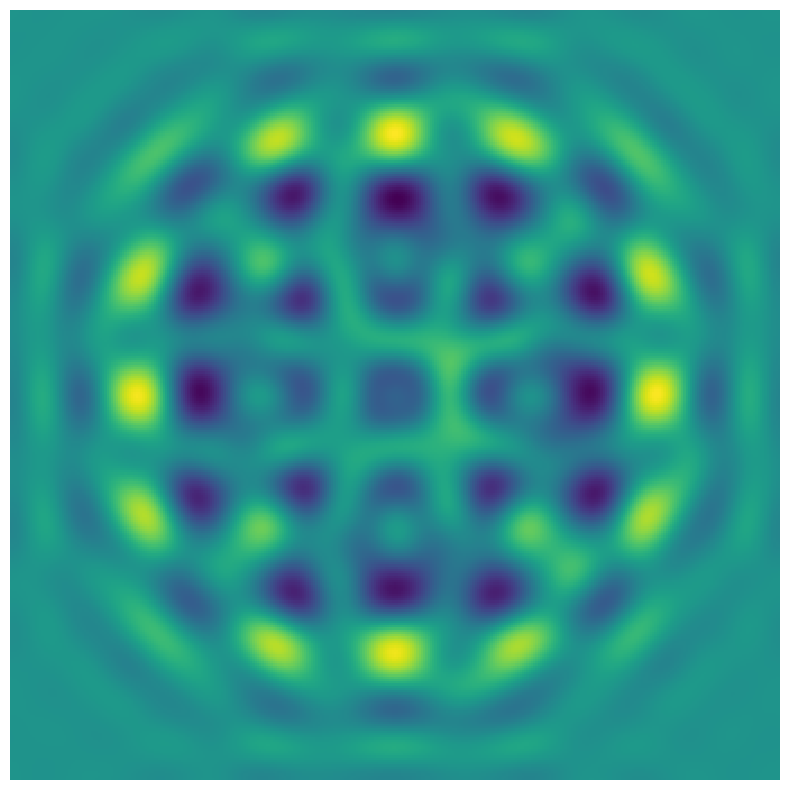

In [8]:
if config['abtem']['status']:
        directory=config['run_dir']/config['simul_dir']/str(config['NP']['seed'])/config['train']['TEM_img_dir']
        NP.abTEM(config,savedir=directory)
